In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')

COL_TR, COL_EN = '#e74c3c', '#3498db'
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv('processed/bertopic_tam_assignments.csv')
topics_df = pd.read_csv('processed/bertopic_tam_topics.csv')
topics_df['words'] = topics_df['Representation'].apply(lambda s: ast.literal_eval(s) if isinstance(s, str) else [])
topics_df['label'] = topics_df['words'].apply(lambda ws: ', '.join(ws[:4]))
topic_label = dict(zip(topics_df['Topic'], topics_df['label']))
topic_label[-1] = 'OUTLIER'

print(f'Yorum: {len(df):,} | Film: {df["imdb_id"].nunique()} | Konu: {(topics_df["Topic"] != -1).sum()}')

Yorum: 382,977 | Film: 229 | Konu: 79


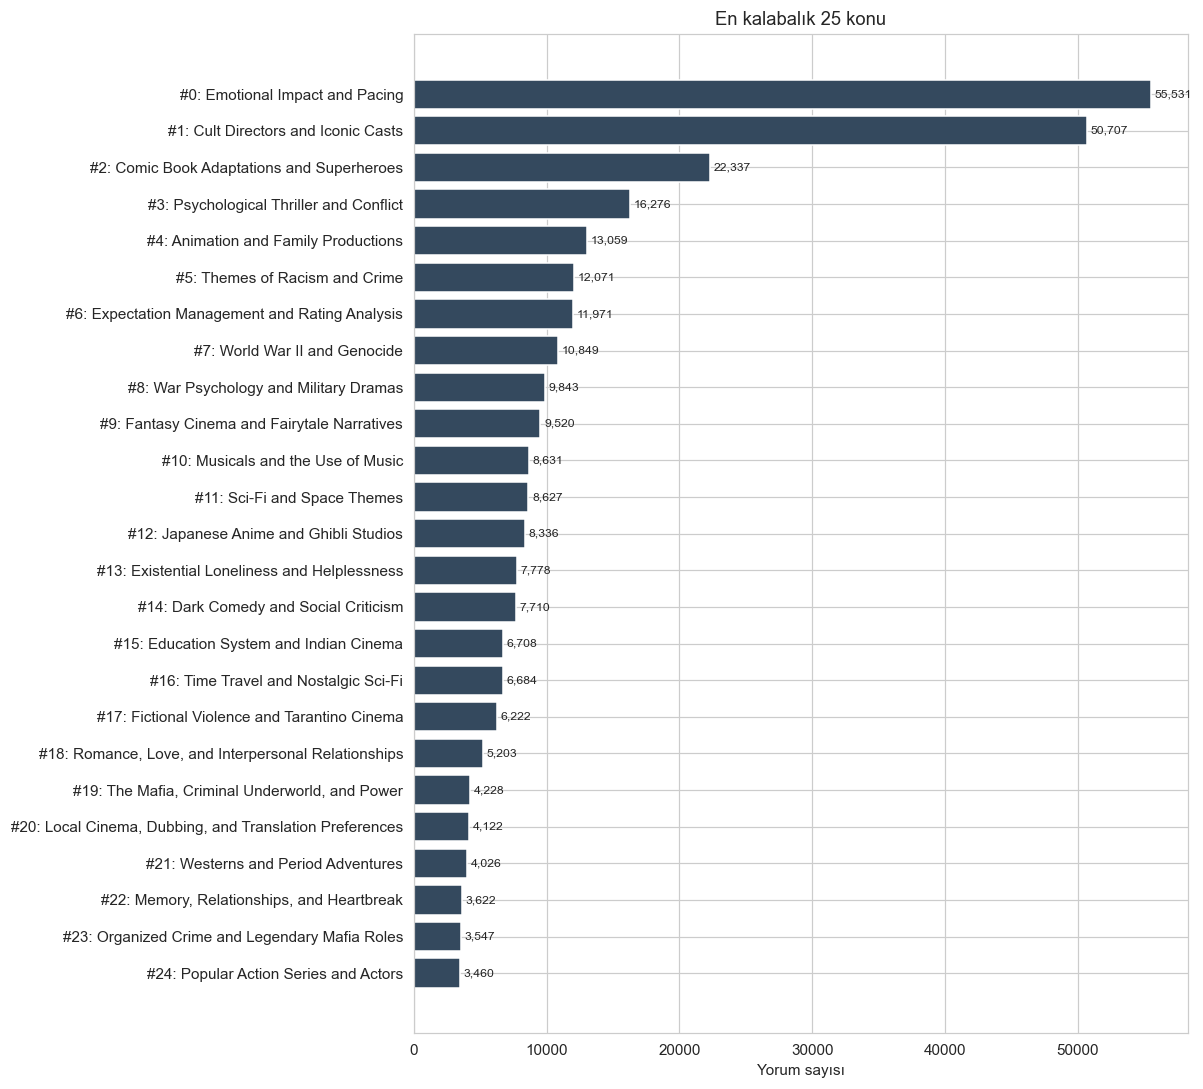

In [10]:
TOP_N = 25
valid = topics_df[topics_df['Topic'] != -1].sort_values('Count', ascending=False).head(TOP_N).copy()

valid['ylabel'] = valid.apply(lambda r: f'#{r["Topic"]}: {r["Title"]}', axis=1)

fig, ax = plt.subplots(figsize=(11, 10))
ax.barh(valid['ylabel'][::-1], valid['Count'][::-1], color='#34495e')
ax.set_xlabel('Yorum sayısı')
ax.set_title(f'En kalabalık {TOP_N} konu')

for i, v in enumerate(valid['Count'][::-1]):
    ax.text(v + max(valid['Count'])*0.005, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout() 
plt.savefig(FIG_DIR / 'bertopic_tam_konu_buyukluk.png')
plt.show()

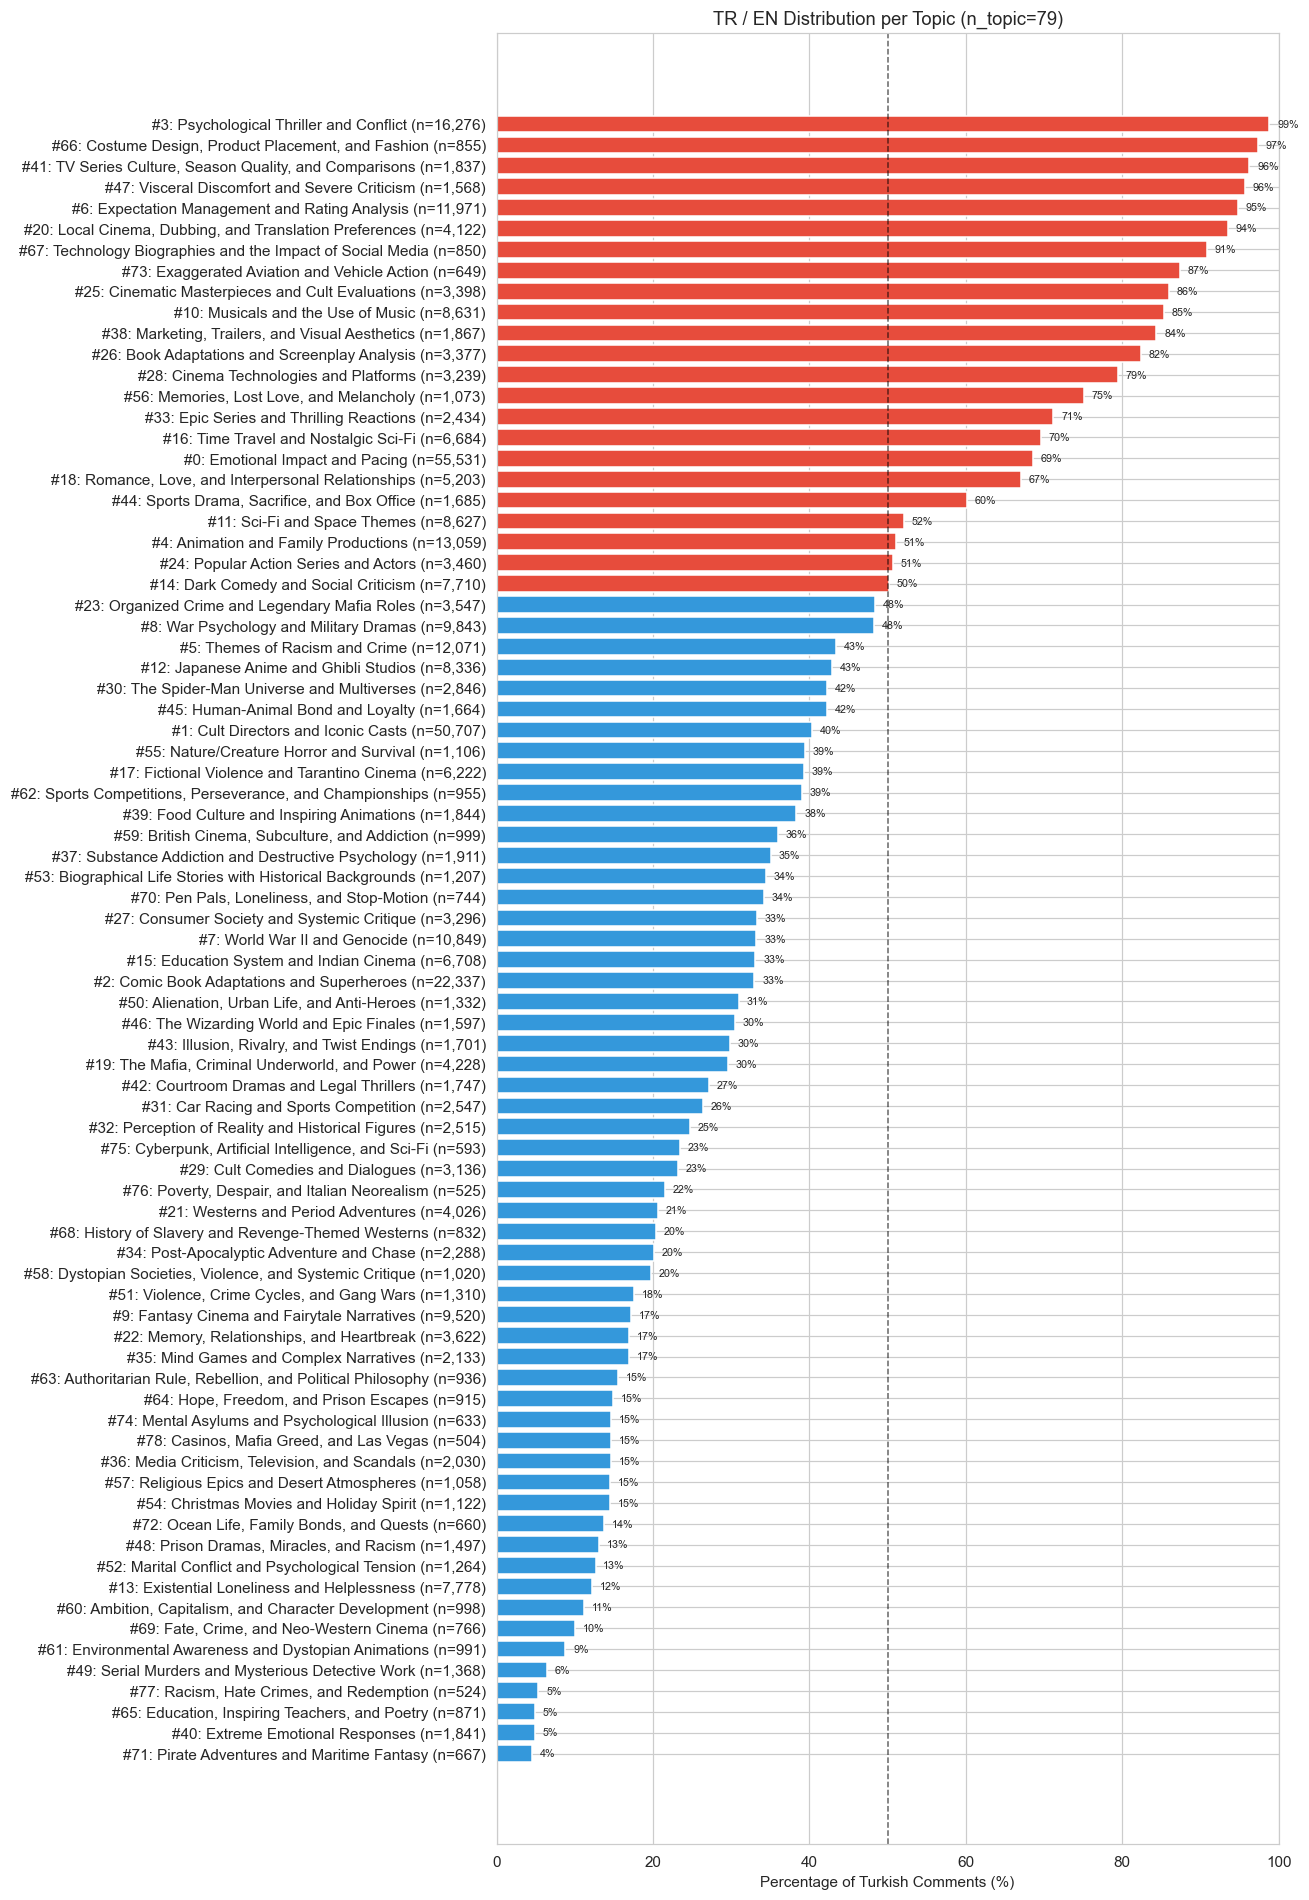

In [11]:
df_v = df[df['topic'] != -1]

topic_title_dict = dict(zip(topics_df['Topic'], topics_df['Title']))
ct = pd.crosstab(df_v['topic'], df_v['language'])
for c in ('tr', 'en'):
    if c not in ct.columns: ct[c] = 0

ct['total'] = ct['tr'] + ct['en']
ct = ct[ct['total'] >= 200].copy()
ct['tr_ratio'] = ct['tr'] / ct['total'] * 100
ct = ct.sort_values('tr_ratio')

ct['label'] = [f'#{t}: {topic_title_dict.get(t, f"Topic {t}")} (n={c:,})' for t, c in zip(ct.index, ct['total'])]

ct['color'] = np.where(ct['tr_ratio'] >= 50, COL_TR, COL_EN)

fig, ax = plt.subplots(figsize=(12, max(8, 0.22 * len(ct))))
ax.barh(ct['label'], ct['tr_ratio'], color=ct['color'], edgecolor='white')
ax.axvline(50, color='black', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Percentage of Turkish Comments (%)')
ax.set_xlim(0, 100)
ax.set_title(f'TR / EN Distribution per Topic (n_topic={len(ct)})')

for i, v in enumerate(ct['tr_ratio']):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / 'bertopic_full_tr_ratio_bar.png')
plt.show()

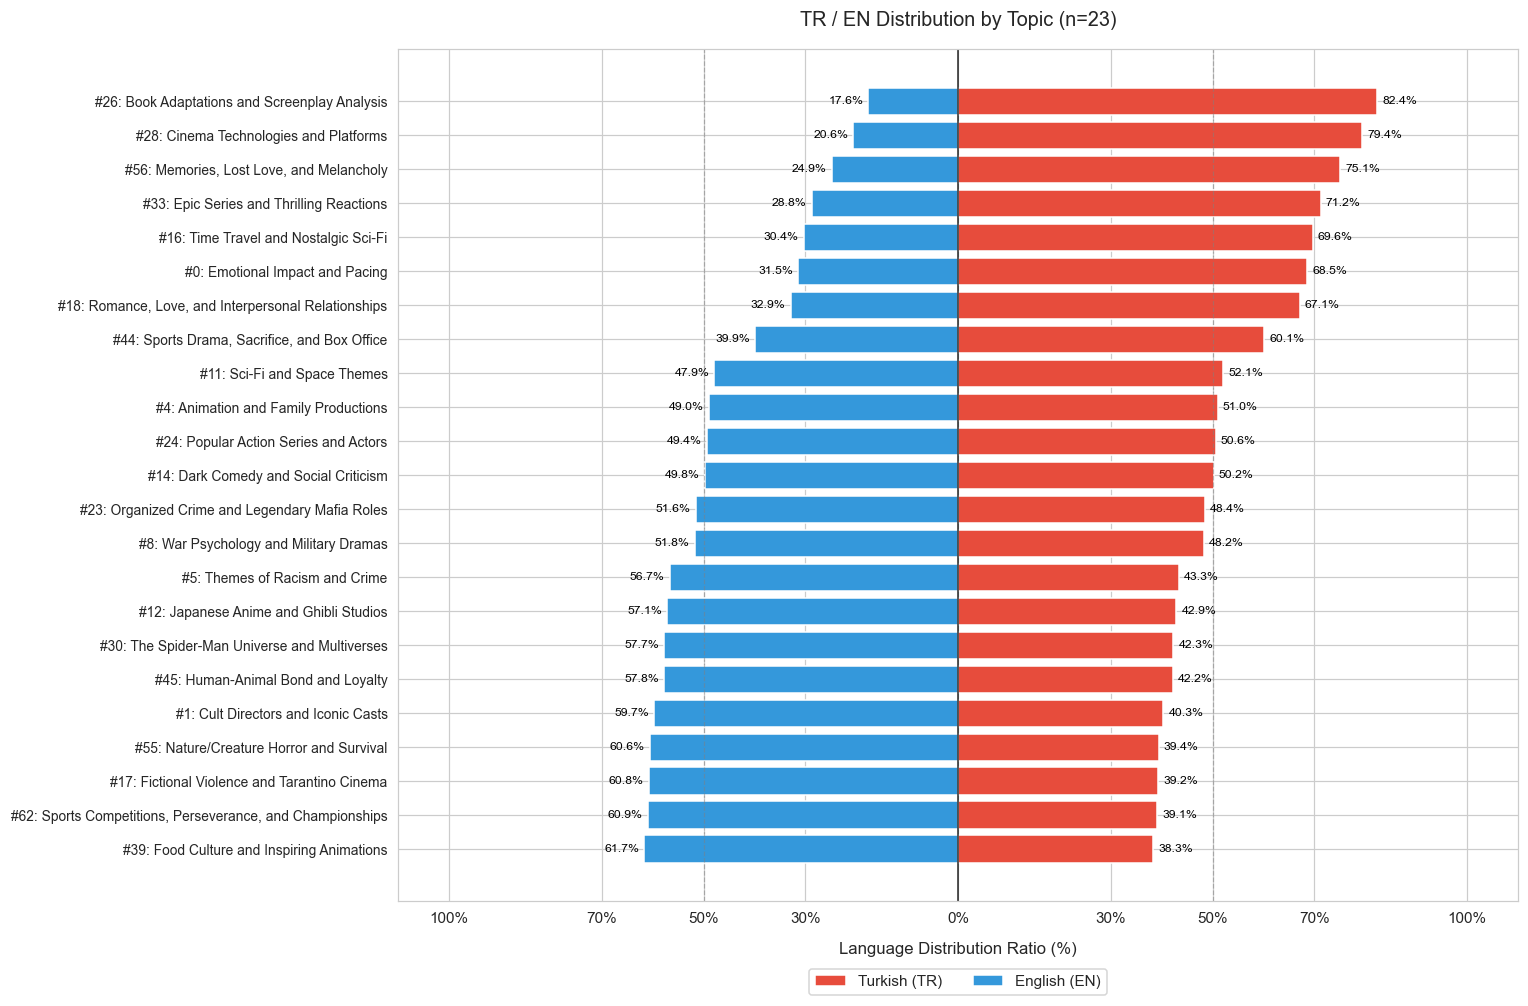

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = result_df.sort_values(by=['Category', 'tr_ratio'], ascending=[True, True])

fig, ax = plt.subplots(figsize=(14, max(8, 0.4 * len(df_plot))))

y_pos = np.arange(len(df_plot))

tr_percents = df_plot['tr_ratio']
en_percents = 100 - df_plot['tr_ratio']

ax.barh(y_pos, tr_percents, color=COL_TR, edgecolor='white', label='Turkish (TR)')
ax.barh(y_pos, -en_percents, color=COL_EN, edgecolor='white', label='English (EN)')

ax.axvline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.7)

ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(-50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

y_labels = [f"[{row['Category']}] #{idx}: {row['Title']}" for idx, row in df_plot.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=9)

for i, (tr, en) in enumerate(zip(tr_percents, en_percents)):
    ax.text(tr + 1, i, f"{tr:.1f}%", va='center', ha='left', fontsize=8, color='black')
    ax.text(-en - 1, i, f"{en:.1f}%", va='center', ha='right', fontsize=8, color='black')

ax.set_xlim(-110, 110)
ax.set_xticks([-100, -70, -50, -30, 0, 30, 50, 70, 100])
ax.set_xticklabels(['100%', '70%', '50%', '30%', '0%', '30%', '50%', '70%', '100%'])

ax.set_xlabel('Language Distribution Ratio (%)', fontsize=11, labelpad=10)
ax.set_title(f'TR / EN Distribution by Category and Topic (30% - 70% TR Range, n={len(df_plot)})', fontsize=13, pad=15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.07), ncol=2, frameon=True)

plt.tight_layout()
plt.savefig(FIG_DIR / 'filtered_topics_lang_distribution.png', dpi=300)
plt.show()